In [1]:
from pathlib import Path
import re

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch as tr


DATA_PATH = Path(
    "/home/gkulemeyer/Documents/Repos/RNADiffusion/"
    "logs/ArchiveII_famfold/srp/t2/seed42"
)

EVAL_DIR = DATA_PATH / "eval/best"

SEQ_FILE = "srp_Acin.baum._CP000521.pt"
NUM_SAMPLES_TO_PLOT = 2


plt.rcParams.update({
    "figure.dpi": 120,
    "axes.spines.top": False,
    "axes.spines.right": False,
})


def get_raw_samples(data):
    """Load raw samples, including compatibility with old files."""
    if "raw_samples" in data:
        return data["raw_samples"]
    return data["samples"]


def get_sample_seeds(data):
    seeds = data.get(
        "sample_seeds",
        data.get("seeds"),
    )

    if seeds is None:
        return None

    return tr.as_tensor(seeds).tolist()


def count_bp(matrix):
    """Count contacts using the upper triangle."""
    return int(
        tr.triu(matrix, diagonal=1).sum().item()
    )


def threshold_from_sample_dir(path):
    """samples_thr0.1 -> 0.1"""
    return float(
        path.name.removeprefix("samples_thr")
    )


def threshold_from_stats_path(path):
    """processed_ensemble_metrics_thr005_stats.csv -> 0.05"""
    match = re.search(
        r"thr(\d+)_stats$",
        path.stem,
    )

    if match is None:
        raise ValueError(
            f"Cannot extract threshold from {path.name}"
        )

    code = match.group(1)

    return float(
        f"{code[0]}.{code[1:] or '0'}"
    )

In [2]:
sample_dirs = sorted(
    EVAL_DIR.glob("samples_thr*"),
    key=threshold_from_sample_dir,
)

if not sample_dirs:
    raise ValueError(
        f"No threshold sample directories found in {EVAL_DIR}"
    )

data_by_threshold = {
    threshold_from_sample_dir(directory): tr.load(
        directory / SEQ_FILE,
        map_location="cpu",
    )
    for directory in sample_dirs
}

thresholds = list(data_by_threshold)

print("Thresholds:", thresholds)

Thresholds: [0.0, 0.05, 0.08, 0.1, 0.12, 0.15, 0.2]


In [3]:
reference_threshold = thresholds[0]
reference = data_by_threshold[reference_threshold]

length = int(reference["length"])

target = reference["target"]

if target.ndim == 3:
    target = target.argmax(dim=0)

target = target[:length, :length]

raw_reference = get_raw_samples(reference)[
    :, :length, :length
]

num_samples_to_plot = min(
    NUM_SAMPLES_TO_PLOT,
    raw_reference.shape[0],
)

print("Sequence:", SEQ_FILE)
print("Length:", length)
print("Number of samples:", raw_reference.shape[0])
print("Sample seeds:", get_sample_seeds(reference))

Sequence: srp_Acin.baum._CP000521.pt
Length: 104
Number of samples: 16
Sample seeds: [42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57]


In [4]:
raw_are_equal = all(
    tr.equal(
        raw_reference,
        get_raw_samples(data)[:, :length, :length],
    )
    for data in data_by_threshold.values()
)

reference_seeds = get_sample_seeds(reference)

seeds_are_equal = all(
    get_sample_seeds(data) == reference_seeds
    for data in data_by_threshold.values()
)

print("Same raw samples across thresholds:", raw_are_equal)
print("Same seeds across thresholds:", seeds_are_equal)

Same raw samples across thresholds: True
Same seeds across thresholds: True


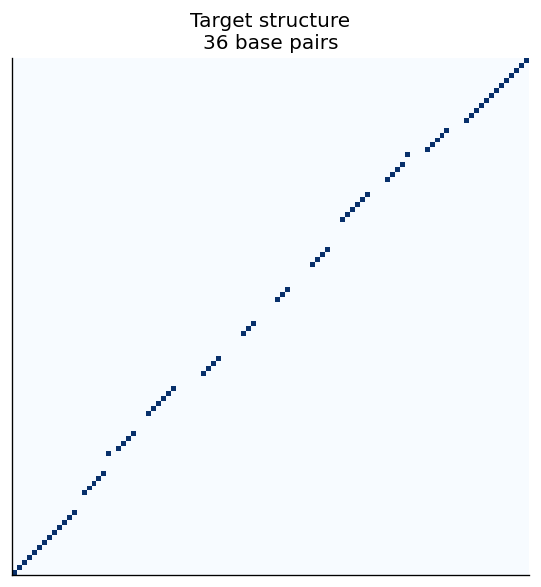

In [5]:
fig, ax = plt.subplots(figsize=(5, 5))

ax.imshow(
    target,
    cmap="Blues",
    vmin=0,
    vmax=1,
    interpolation="nearest",
)

ax.set_title(
    f"Target structure\n"
    f"{count_bp(target)} base pairs"
)

ax.set_xticks([])
ax.set_yticks([])
ax.set_aspect("equal")

fig.tight_layout()
plt.show()

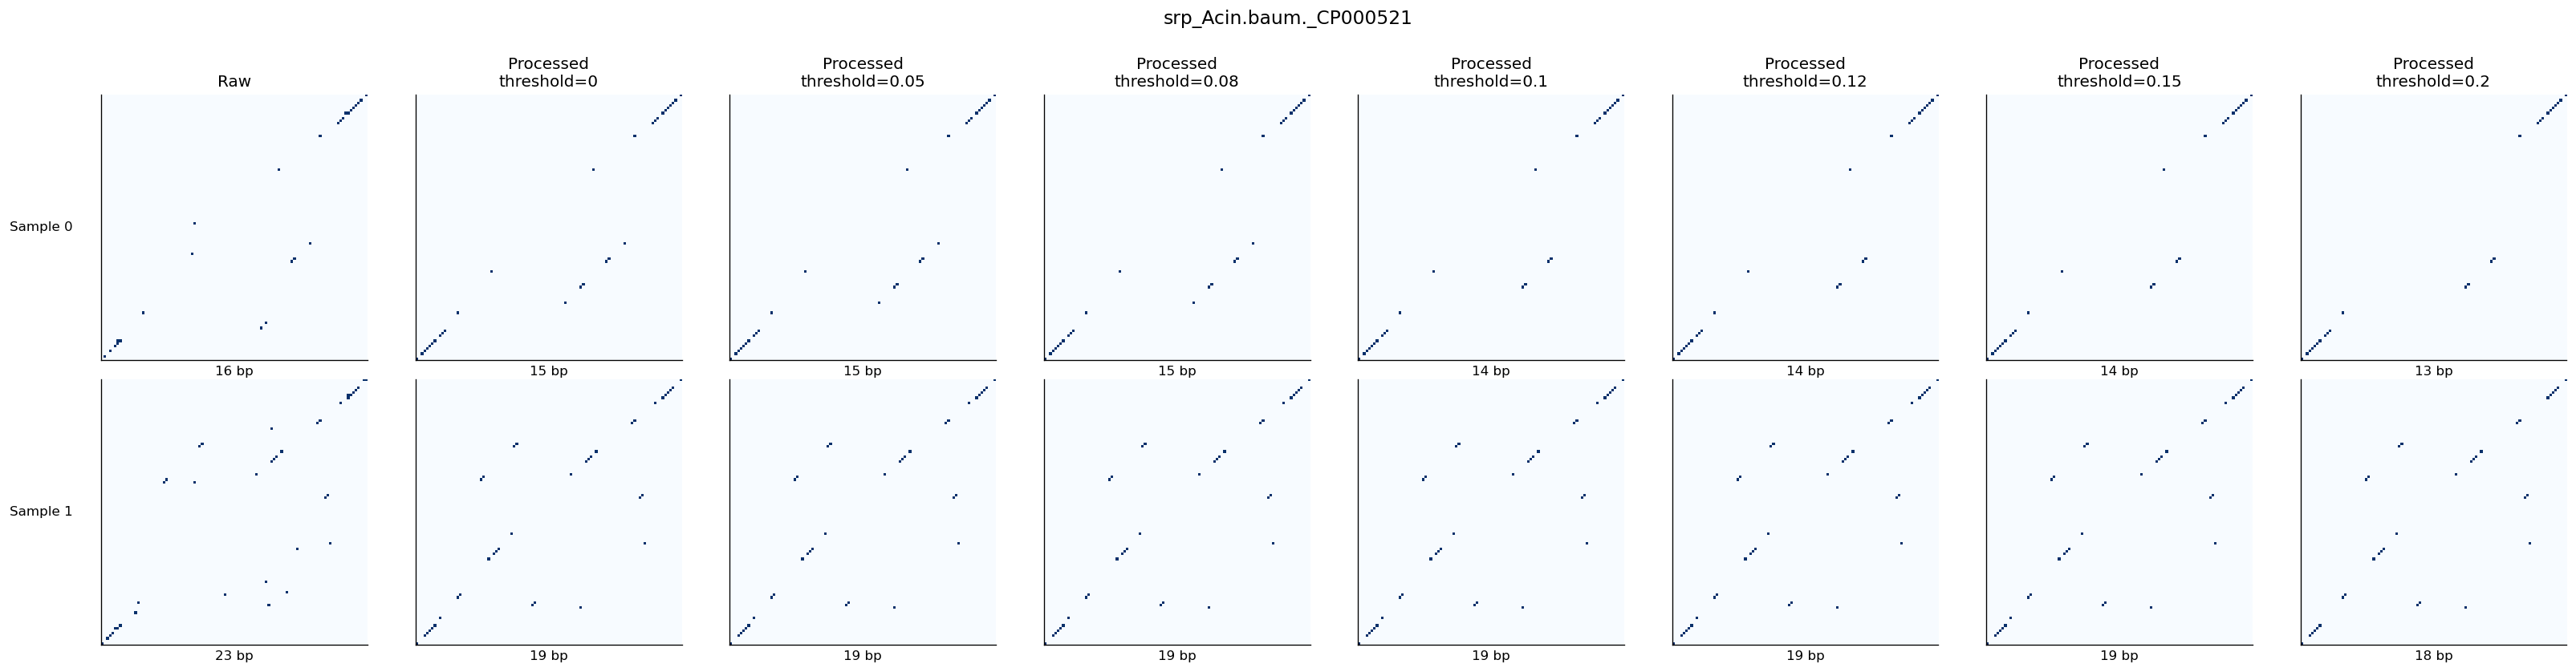

In [6]:
ncols = 1 + len(thresholds)

fig, axes = plt.subplots(
    num_samples_to_plot,
    ncols,
    figsize=(
        3.4 * ncols,
        3.4 * num_samples_to_plot,
    ),
    squeeze=False,
    sharex=True,
    sharey=True,
)

for sample_id in range(num_samples_to_plot):
    raw_sample = raw_reference[sample_id]

    # Raw sample
    ax = axes[sample_id, 0]

    ax.imshow(
        raw_sample,
        cmap="Blues",
        vmin=0,
        vmax=1,
        interpolation="nearest",
    )

    ax.set_ylabel(
        f"Sample {sample_id}",
        rotation=0,
        labelpad=45,
        va="center",
    )

    ax.set_xlabel(
        f"{count_bp(raw_sample)} bp"
    )

    if sample_id == 0:
        ax.set_title("Raw")

    # Processed samples
    for column, threshold in enumerate(
        thresholds,
        start=1,
    ):
        processed_sample = data_by_threshold[
            threshold
        ]["processed_samples"][
            sample_id,
            :length,
            :length,
        ]

        ax = axes[sample_id, column]

        ax.imshow(
            processed_sample,
            cmap="Blues",
            vmin=0,
            vmax=1,
            interpolation="nearest",
        )

        ax.set_xlabel(
            f"{count_bp(processed_sample)} bp"
        )

        if sample_id == 0:
            ax.set_title(
                f"Processed\nthreshold={threshold:g}"
            )

for ax in axes.flat:
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_aspect("equal")

fig.suptitle(
    SEQ_FILE.removesuffix(".pt"),
    fontsize=14,
    y=1.01,
)

fig.tight_layout()
plt.show()

In [7]:
sample_comparison = []

for sample_id in range(num_samples_to_plot):
    raw_sample = raw_reference[sample_id]
    raw_bp = count_bp(raw_sample)

    for threshold, data in data_by_threshold.items():
        processed_sample = data[
            "processed_samples"
        ][sample_id, :length, :length]

        processed_bp = count_bp(
            processed_sample
        )

        sample_comparison.append({
            "sample_id": sample_id,
            "threshold": threshold,
            "raw_bp": raw_bp,
            "processed_bp": processed_bp,
            "removed_bp": raw_bp - processed_bp,
        })

sample_comparison = pd.DataFrame(
    sample_comparison
)

sample_comparison

,sample_id,threshold,raw_bp,processed_bp,removed_bp
0,0,0.00,16,15,1
1,0,0.05,16,15,1
2,0,0.08,16,15,1
3,0,0.10,16,14,2
4,0,0.12,16,14,2
5,0,0.15,16,14,2
6,0,0.20,16,13,3
7,1,0.00,23,19,4
8,1,0.05,23,19,4
9,1,0.08,23,19,4


In [9]:
processed_stats_paths = sorted(
    EVAL_DIR.glob(
        "samples_stats*/"
        "processed_ensemble_metrics_thr*_stats.csv"
    ),
    key=threshold_from_stats_path,
)

if not processed_stats_paths:
    raise ValueError(
        f"No processed stats files found in {EVAL_DIR}"
    )

processed_stats = pd.concat(
    [
        pd.read_csv(path).assign(
            threshold=threshold_from_stats_path(path)
        )
        for path in processed_stats_paths
    ],
    ignore_index=True,
)

processed_stats = (
    processed_stats
    .sort_values(["threshold", "consensus"])
    .reset_index(drop=True)
)

for path in processed_stats_paths:
    print(
        f"threshold={threshold_from_stats_path(path):g}: "
        f"{path.relative_to(EVAL_DIR)}"
    )
RAW_STATS_PATH = (
    EVAL_DIR / "raw_ensemble_stats.csv"
)

raw_stats = (
    pd.read_csv(RAW_STATS_PATH)
    .sort_values("consensus")
    .reset_index(drop=True)
)

raw_stats

threshold=0: samples_stats00/processed_ensemble_metrics_thr00_stats.csv
threshold=0.05: samples_stats005/processed_ensemble_metrics_thr005_stats.csv
threshold=0.08: samples_stats008/processed_ensemble_metrics_thr008_stats.csv
threshold=0.1: samples_stats01/processed_ensemble_metrics_thr01_stats.csv
threshold=0.12: samples_stats012/processed_ensemble_metrics_thr012_stats.csv
threshold=0.15: samples_stats015/processed_ensemble_metrics_thr015_stats.csv
threshold=0.2: samples_stats02/processed_ensemble_metrics_thr02_stats.csv


,consensus,mean,std,std_mean,std_std,best,worst
0,1,0.167910,0.144518,0.029007,0.023995,0.201879,0.134484
1,3,0.167596,0.162791,0.021457,0.019020,0.193130,0.143626
2,5,0.165102,0.166397,0.017748,0.017724,0.185695,0.144886
3,7,0.162797,0.169978,0.014394,0.015237,0.179603,0.146768


In [10]:
raw_table = (
    raw_stats
    .set_index("consensus")["mean"]
    .rename("raw")
)

processed_table = processed_stats.pivot(
    index="consensus",
    columns="threshold",
    values="mean",
)

processed_table.columns = [
    f"processed_thr{threshold:g}"
    for threshold in processed_table.columns
]

f1_comparison = pd.concat(
    [raw_table, processed_table],
    axis=1,
)

f1_comparison

,raw,processed_thr0,processed_thr0.05,processed_thr0.08,processed_thr0.1,processed_thr0.12,processed_thr0.15,processed_thr0.2
consensus,,,,,,,,
1,0.167910,0.168936,0.170029,0.171308,0.171809,0.171688,0.171475,0.168895
3,0.167596,0.162729,0.162735,0.162744,0.162732,0.162624,0.162349,0.161468
5,0.165102,0.160554,0.160554,0.160554,0.160558,0.160511,0.160460,0.160098
7,0.162797,0.158725,0.158725,0.158725,0.158698,0.158669,0.158721,0.158647


In [13]:
processed_stats["raw_mean"] = (
    processed_stats["consensus"]
    .map(raw_table)
)

processed_stats["delta_vs_raw"] = (
    processed_stats["mean"]
    - processed_stats["raw_mean"]
)

processed_stats["relative_delta_vs_raw"] = (
    100
    * processed_stats["delta_vs_raw"]
    / processed_stats["raw_mean"]
)

processed_stats[
    [
        "threshold",
        "consensus",
        "raw_mean",
        "mean",
        "delta_vs_raw",
        "relative_delta_vs_raw",
    ]
]

,threshold,consensus,raw_mean,mean,delta_vs_raw,relative_delta_vs_raw
0,0.00,1,0.167910,0.168936,0.001026,0.610958
1,0.00,3,0.167596,0.162729,-0.004867,-2.904115
2,0.00,5,0.165102,0.160554,-0.004548,-2.754558
3,0.00,7,0.162797,0.158725,-0.004072,-2.501134
4,0.05,1,0.167910,0.170029,0.002119,1.262129
5,0.05,3,0.167596,0.162735,-0.004861,-2.900658
6,0.05,5,0.165102,0.160554,-0.004548,-2.754558
7,0.05,7,0.162797,0.158725,-0.004072,-2.501134
8,0.08,1,0.167910,0.171308,0.003398,2.023705
9,0.08,3,0.167596,0.162744,-0.004853,-2.895457


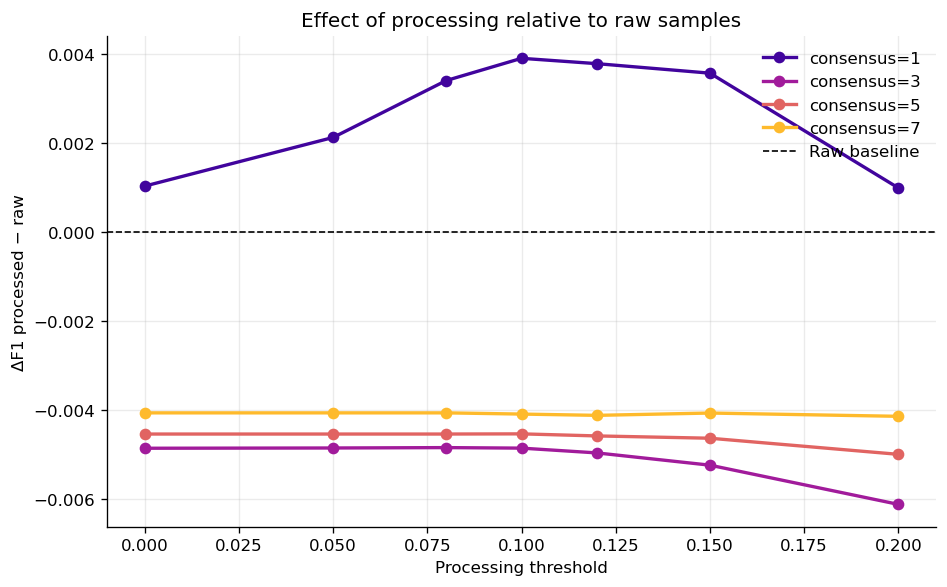

In [14]:
fig, ax = plt.subplots(figsize=(8, 5))

consensus_values = sorted(
    processed_stats["consensus"].unique()
)

colors = plt.cm.plasma(
    np.linspace(0.1, 0.85, len(consensus_values))
)

for color, consensus in zip(
    colors,
    consensus_values,
):
    stats = (
        processed_stats[
            processed_stats["consensus"] == consensus
        ]
        .sort_values("threshold")
    )

    ax.plot(
        stats["threshold"],
        stats["delta_vs_raw"],
        marker="o",
        linewidth=2,
        color=color,
        label=f"consensus={consensus}",
    )

ax.axhline(
    0,
    color="black",
    linestyle="--",
    linewidth=1,
    label="Raw baseline",
)

ax.set(
    xlabel="Processing threshold",
    ylabel="ΔF1 processed − raw",
    title="Effect of processing relative to raw samples",
)

ax.grid(alpha=0.25)
ax.legend(frameon=False)

fig.tight_layout()
plt.show()

In [17]:
best_global = (
    processed_stats
    .sort_values(
        "delta_vs_raw",
        ascending=False,
    )
    .iloc[0]
)

best_global[
    [
        "consensus",
        "threshold",
        "raw_mean",
        "mean",
        "delta_vs_raw",
        "relative_delta_vs_raw",
    ]
]

consensus                1.000000
threshold                0.100000
raw_mean                 0.167910
mean                     0.171809
delta_vs_raw             0.003898
relative_delta_vs_raw    2.321649
Name: 12, dtype: float64